In [1]:
import numpy as np
from TestAv2 import TestAv2RL
from stable_baselines3 import PPO
from gym_pybullet_drones.envs.BaseAviary import DroneModel

In [2]:
ep_len = 2 # sec

drone_model = DroneModel.CF2X

env = TestAv2RL(drone_model=drone_model, ep_len=ep_len, freq=240)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [3]:
import os
from stable_baselines3.common.monitor import Monitor

log_dir = "C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/AttitudeThroughPosition/attitude_sb3_logs"
os.makedirs(log_dir, exist_ok=True)
env = Monitor(env, log_dir)

In [4]:
from stable_baselines3.common.callbacks import EvalCallback
eval_env = TestAv2RL(drone_model=drone_model, ep_len=ep_len, freq=240)
eval_env = Monitor(eval_env)

eval_callback = EvalCallback(eval_env,
            log_path="C:/Users/awals/OneDrive/Documents/Academic/DDP/Implementations/AttitudeThroughPosition/attitude_sb3_logs",
            n_eval_episodes=2,
            eval_freq=1000,
            deterministic=True) 

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


In [5]:
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=300000, callback=eval_callback)

Using cuda device
Wrapping the env in a DummyVecEnv.
Eval num_timesteps=1000, episode_reward=-162.07 +/- 0.00
Episode length: 481.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 481      |
|    mean_reward     | -162     |
| time/              |          |
|    total_timesteps | 1000     |
---------------------------------
New best mean reward!
Eval num_timesteps=2000, episode_reward=-162.07 +/- 0.00
Episode length: 481.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 481      |
|    mean_reward     | -162     |
| time/              |          |
|    total_timesteps | 2000     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 481      |
|    ep_rew_mean     | -579     |
| time/              |          |
|    fps             | 218      |
|    iterations      | 1        |
|    time_elapsed    | 9        |

In [6]:
model.save("attitude_sb3_logs/TestAv2_PPO1")

In [7]:
history = np.load("attitude_sb3_logs/evaluations.npz")
rewards = np.average(history["results"], axis=1)
print(rewards.shape)

(301,)


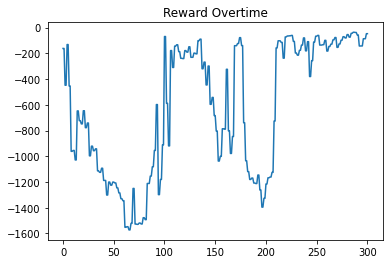

In [8]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.title("Reward Overtime")
plt.show()

In [9]:
ep_len = 2 # sec

cumm_reward = 0
curr_rpys = []
computed_target_rpys = []
obs = env.reset()
for i in range(ep_len*env.SIM_FREQ):
    # extracting relevant info
    computed_target_rpy = obs[6:]
    computed_target_rpys.append(computed_target_rpy)
    curr_rpys.append(obs[3:6])

    # computing next action
    action, _ = model.predict(obs)
    
    # stepping the environment
    obs, reward, done, info = env.step(action)

    # accumulating reward over episode
    cumm_reward += reward

print(cumm_reward)

-106.24058320251494


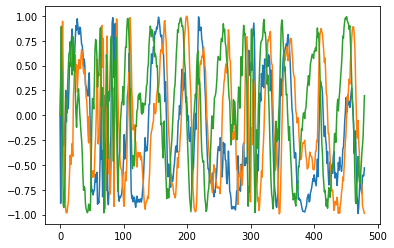

In [15]:
plt.plot(np.array(computed_target_rpys)-np.array(curr_rpys))
plt.show()

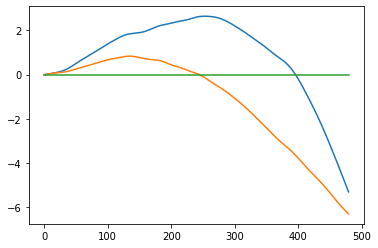

In [11]:
plt.plot(np.array(computed_target_rpys)*180/np.pi)
plt.show()